In [1]:
from feos import * #EquationOfState, State, Contributions
from feos.parameters import * #Parameters, PureRecord, Identifier

import si_units as si

import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt


# Dimensioned (methanol)

In [2]:
# Lafitte Methanol parameters

methanol_saft_vr_mie = {
    "identifier": Identifier(name="methanol"),
    "molarweight": 32.026,
    "m": 1.5283,
    "sigma": 3.3063,
    "epsilon_k": 167.72,
    "rep": 8.6556,
    "att": 6.0,
    "association_sites": [
      {
        "na": 1.0,
        "nb": 1.0,
        "rc_ab": 0.41314,
        "rd_ab": 0.4,
        "epsilon_k_ab": 2904.7
      }
    ]
}

pr = PureRecord(**methanol_saft_vr_mie)
parameters = Parameters.new_pure(pr)

model = EquationOfState.uvtheory(
    parameters,
    perturbation="WCA_TPT",
    combination_rule="one_fluid_psi",
    chain_contribution="tpt1y"
)

temperature = 2.0 * 167.72 * si.KELVIN
density = 100 * si.MOL / si.METER**3
state = State(model, temperature=temperature, density=density)

for n, c in state.residual_molar_helmholtz_energy_contributions():
    print(f"{n:<30}: {c / (si.RGAS * temperature):>12.8f}")
    #print(f"{n:<30}: {c}")

Hard Sphere (WCA, TPT)        :   0.00947711
Mie Chain                     :  -0.00055710
Reference Perturbation (WCA)  :   0.00085121
Attractive Perturbation (WCA) :  -0.02223419
Association                   :  -0.26064595


In [3]:
phase_diagram = PhaseDiagram.pure(model, 180 * si.KELVIN, 25)

# Reduced

In [4]:
reduced = {
    "identifier": Identifier(),
    "molarweight": 1.0,
    "m": 1.0,
    "sigma": 1.0,
    "epsilon_k": 1.0,
    "rep": 12.0, 
    "att": 6.0,
    "association_sites": [
      {
        "na": 0.0,
        "nb": 0.0,
        "nc": 1.0,
        "rc_ab": 0.2,
        "rd_ab": 0.4,
        "epsilon_k_ab": 20.0
      }
    ]
}

pr = PureRecord(**reduced)
parameters = Parameters.new_pure(pr)
model = EquationOfState.uvtheory(
    parameters,
    perturbation="WCA_TPT",
    combination_rule="one_fluid_psi",
    chain_contribution="tpt1y",
    association_model="tvw"
)


reduced = {
    "identifier": Identifier(),
    "molarweight": 1.0,
    "m": 1.0,
    "sigma": 1.0,
    "epsilon_k": 1.0,
    "lr": 12.0, 
    "la": 6.0,
    "association_sites": [
      {
        "na": 0.0,
        "nb": 0.0,
        "nc": 1.0,
        "rc_ab": 0.2,
        "rd_ab": 0.4,
        "epsilon_k_ab": 20.0
      }
    ]
}
pr = PureRecord(**reduced)
parameters = Parameters.new_pure(pr)

model2 = EquationOfState.saftvrmie(parameters)

density = 0.15 / si.ANGSTROM**3 / si.NAV
temperature=2.0 * si.KELVIN

state = State(model, temperature=temperature, density=density)
for n, c in state.residual_molar_helmholtz_energy_contributions():
    print(f"{n:<30}: {c / (si.RGAS * temperature):>12.8f}")

Hard Sphere (WCA, TPT)        :   0.31388301
Mie Chain                     :   0.00000000
Reference Perturbation (WCA)  :   0.02291829
Attractive Perturbation (WCA) :  -0.51821650
Association                   :  -0.14520953


In [10]:
phase_diagram = PhaseDiagram.pure(model, 1 * si.KELVIN, 500)

In [11]:
phase_diagram2 = PhaseDiagram.pure(model2, 1 * si.KELVIN, 500)

In [12]:
MC1 = pd.read_csv("MC_VLE_eps10_Johnson1993.txt",sep = r'\s+')
MC2 = pd.read_csv("MC_VLE_eps10_Johnson1994.txt",sep = r'\s+')
MC3 = pd.read_csv("MC_VLE_eps20_Johnson1994.txt",sep = r'\s+')

In [13]:
MC3

,t,rho_l,rho_v
0,1.20,0.767378,0.007178
1,1.30,0.728180,0.017235
2,1.40,0.677539,0.030771
3,1.50,0.626398,0.058240
4,1.60,0.544417,0.142926
5,1.65,0.460390,0.158402
6,1.65,0.438003,0.207157


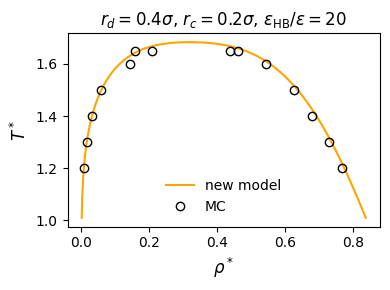

In [29]:
plt.figure(figsize=[4,3])

plt.plot(phase_diagram.liquid.density * si.NAV *1.E-30 * si.METER**3, 
         phase_diagram.liquid.temperature / si.KELVIN, '-',color='orange',label=r'new model')
plt.plot(phase_diagram.vapor.density * si.NAV *1.E-30 * si.METER**3, 
         phase_diagram.vapor.temperature / si.KELVIN, '-', color='orange')

# plt.plot(phase_diagram2.liquid.density * si.NAV *1.E-30 * si.METER**3, 
#          phase_diagram2.liquid.temperature / si.KELVIN, '-',color='tab:orange',label='SAFT-VR-Mie')
# plt.plot(phase_diagram2.vapor.density * si.NAV *1.E-30 * si.METER**3, 
#          phase_diagram2.vapor.temperature / si.KELVIN, '-',color='tab:orange')


# plt.plot(MC1['rho_v'],MC1['t'],'x',mec='black',mfc='None')
# plt.plot(MC1['rho_l'],MC1['t'],'x',mec='black',mfc='None')

# plt.plot(MC2['rho_v'],MC2['t'],'o',mec='black',mfc='None')
# plt.plot(MC2['rho_l'],MC2['t'],'o',mec='black',mfc='None')

plt.plot(MC3['rho_v'],MC3['t'],'o',mec='black',mfc='None',label='MC')
plt.plot(MC3['rho_l'],MC3['t'],'o',mec='black',mfc='None')

plt.legend(frameon=False)
plt.title(r'$r_d=0.4\sigma$, $r_c = 0.2\sigma$, $\epsilon_{\rm  HB}/\epsilon = 20$')
plt.xlabel(r'$\rho^*$',fontsize=12)
plt.ylabel(r'$T^*$',fontsize=12)
plt.tight_layout()
plt.savefig('association.pdf')